# EDA completa - Vacinação contra sarampo (SI-PNI/RNDS, jan/2025 a jun/2026)

Análise exploratória de **toda a base silver** (`data/vacinacao/processed/silver/vacinacao_sarampo_sipni.parquet`): 11,76 milhões de doses de vacinas com componente de sarampo (tríplice viral SCR, tetra viral SCRV, dupla viral SR), uma linha por dose.

Complementa os notebooks anteriores:
- [05-silver-qualidade-vacinacao.ipynb](05-silver-qualidade-vacinacao.ipynb): qualidade e funil de processamento.
- [06-gold-panorama-vacinacao.ipynb](06-gold-panorama-vacinacao.ipynb) e [07-gold-criancas-municipios-atraso.ipynb](07-gold-criancas-municipios-atraso.ipynb): panorama e crianças/municípios (sobre a gold).

Aqui cada variável é explorada individualmente e depois cruzada com as demais, direto sobre a silver. **Uso de memória: ~5 GB de RAM.**

Índice: 1. Visão geral · 2. Tempo · 3. Vacina e dose · 4. Pessoa e intervalo entre doses · 5. Demografia · 6. Geografia e deslocamento · 7. Estabelecimentos · 8. Estratégias · 9. Adultos · 10. Síntese

## 1. Visão geral

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Paleta categorica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE = "#2a78d6"
TEXT_PRIMARY, TEXT_SECONDARY, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY, "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 40

SILVER = Path("..") / "data" / "vacinacao" / "processed" / "silver" / "vacinacao_sarampo_sipni.parquet"
SEM = "Sem registro"
ORDEM_IDADE = ["<1", "1", "2-4", "5-9", "10-14", "15-19", "20-29", "30-39", "40-49", "50-59", "60+"]


def milhar(ax, eixo="y"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
    (ax.yaxis if eixo == "y" else ax.xaxis).set_major_formatter(fmt)


def titulo(ax, texto):
    ax.set_title(texto, loc="left", fontweight="bold")


def empilhado_pct(ax, tabela, cores=None, legenda_col=4):
    """Barras empilhadas 100%: tabela com linhas = categorias do eixo x, colunas = fatias."""
    pct = tabela.div(tabela.sum(axis=1), axis=0) * 100
    base = np.zeros(len(pct))
    for cor, col in zip(cores or CATEGORICAL, pct.columns):
        ax.bar(pct.index.astype(str), pct[col], bottom=base, label=col, color=cor)
        base += pct[col].values
    ax.set_ylabel("% das doses"); ax.set_ylim(0, 100)
    ax.legend(frameon=False, ncol=legenda_col, loc="upper center", bbox_to_anchor=(0.5, -0.22))
    return pct

df = pd.read_parquet(SILVER)
print(f"{len(df):,} doses | {df['codigo_paciente_anonimizado'].nunique():,} pacientes distintos | "
      f"{df['data_vacinacao'].min():%d/%m/%Y} a {df['data_vacinacao'].max():%d/%m/%Y}")

dic = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "% nulos": df.isna().mean() * 100,
    "únicos": df.nunique(),
    "exemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
dic

11,757,577 doses | 8,785,306 pacientes distintos | 01/01/2025 a 30/06/2026


,tipo,% nulos,únicos,exemplo
codigo_paciente_anonimizado,str,0.00,8785306,0062aaff6663abdbe1b004b07b87d866997e97de24dbf8...
sexo_paciente,string,0.00,3,Masculino
raca_cor_paciente,string,0.00,6,PARDA
codigo_municipio_paciente,str,1.68,5587,330455
uf_paciente,string,1.69,28,RJ
nacionalidade_paciente,string,0.01,3,B
etnia_indigena_paciente,string,99.53,345,"YANOMAMI NINAM (IANOMAMI, IANOAMA, XIRIA­NA)"
codigo_cnes_estabelecimento,str,0.00,43541,7892829
codigo_municipio_estabelecimento,str,0.00,5571,330455
uf_estabelecimento,string,0.00,27,RJ


## 2. Tempo

### 2.1 Ano contra ano: jan-jun/2025 x jan-jun/2026
O primeiro semestre dos dois anos é comparável mês a mês.

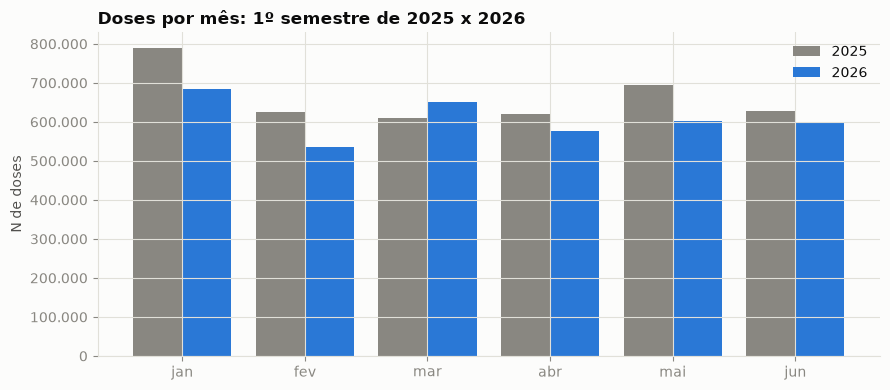

Variação 2026/2025 por mês (%): {1: -13.3, 2: -14.3, 3: 6.8, 4: -6.9, 5: -13.2, 6: -4.8}
Semestre: 2025 = 3,968,134 | 2026 = 3,650,725 | -8.0%


In [2]:
df["ano"] = df["data_vacinacao"].dt.year
df["mes"] = df["data_vacinacao"].dt.month
sem = df[df["mes"] <= 6].groupby(["mes", "ano"]).size().unstack()
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(sem))
ax.bar(x - 0.2, sem[2025], 0.4, label="2025", color=MUTED)
ax.bar(x + 0.2, sem[2026], 0.4, label="2026", color=BLUE)
ax.set_xticks(x); ax.set_xticklabels(["jan", "fev", "mar", "abr", "mai", "jun"])
titulo(ax, "Doses por mês: 1º semestre de 2025 x 2026"); ax.set_ylabel("N de doses"); milhar(ax); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
var = (sem[2026] / sem[2025] - 1) * 100
print("Variação 2026/2025 por mês (%):", var.round(1).to_dict())
print(f"Semestre: 2025 = {sem[2025].sum():,} | 2026 = {sem[2026].sum():,} | {(sem[2026].sum()/sem[2025].sum()-1)*100:+.1f}%")

### 2.2 Dia da semana e dia do mês
A vacinação de rotina ocorre em dias úteis; o dia do mês revela efeitos de fim de mês e de registro em lote.

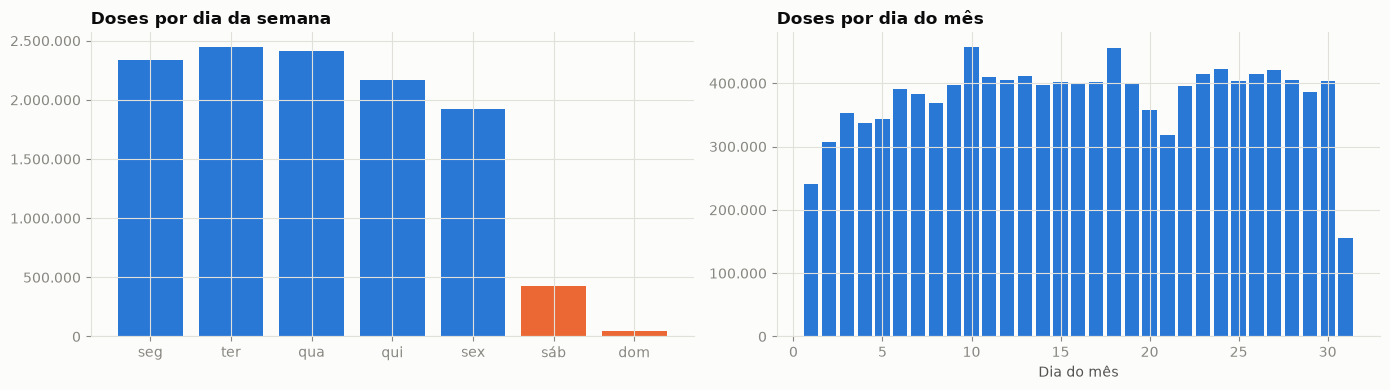

Fim de semana: 4.0% das doses


In [3]:
dias = ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"]
dow = df["data_vacinacao"].dt.dayofweek.value_counts().sort_index()
dom = df["data_vacinacao"].dt.day.value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(dias, dow.values, color=[BLUE] * 5 + [CATEGORICAL[1]] * 2); titulo(axes[0], "Doses por dia da semana"); milhar(axes[0])
axes[1].bar(dom.index, dom.values, color=BLUE); titulo(axes[1], "Doses por dia do mês"); milhar(axes[1]); axes[1].set_xlabel("Dia do mês")
plt.tight_layout(); plt.show()
print(f"Fim de semana: {(dow[5] + dow[6]) / dow.sum() * 100:.1f}% das doses")

### 2.3 Calendário: mês x dia da semana
Mostra se campanhas de sábado (dia D) mudam o padrão semanal em algum mês.

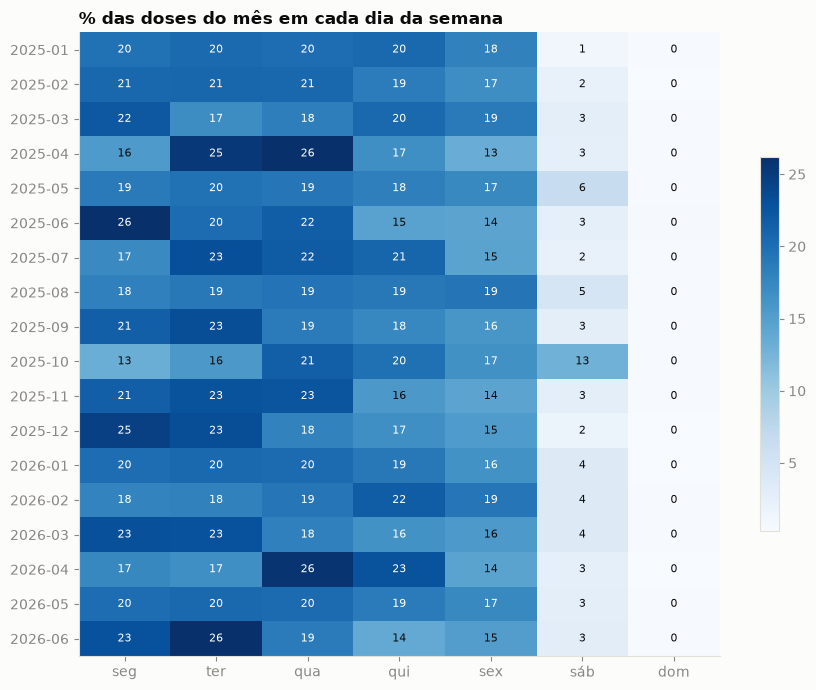

In [4]:
cal = df.groupby(["ano_mes", df["data_vacinacao"].dt.dayofweek]).size().unstack().fillna(0)
cal = cal.div(cal.sum(axis=1), axis=0) * 100
cal.columns = dias
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cal.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(7)); ax.set_xticklabels(cal.columns); ax.set_yticks(range(len(cal))); ax.set_yticklabels(cal.index); ax.grid(False)
for i in range(cal.shape[0]):
    for j in range(cal.shape[1]):
        ax.text(j, i, f"{cal.values[i, j]:.0f}", ha="center", va="center", fontsize=8,
                color="white" if cal.values[i, j] > cal.values.max() * 0.6 else TEXT_PRIMARY)
titulo(ax, "% das doses do mês em cada dia da semana")
fig.colorbar(im, ax=ax, shrink=0.6); plt.tight_layout(); plt.show()

## 3. Vacina e dose

### 3.1 Tipo de vacina x faixa etária
Cada faixa etária tem um produto característico: a tetra viral (SCRV) é dada aos 15 meses; a SCR cobre o resto.

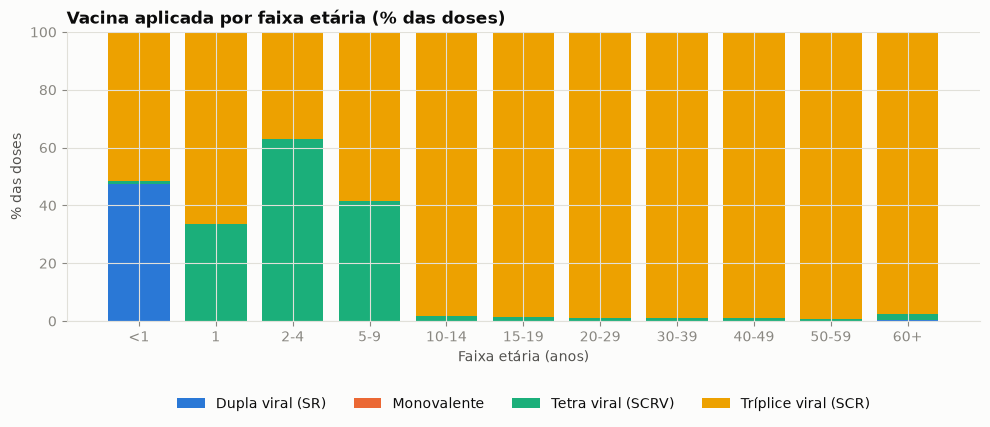

vacina_tipo,Dupla viral (SR),Monovalente,Tetra viral (SCRV),Tríplice viral (SCR)
faixa_etaria,,,,
<1,47.40,0.10,0.90,51.60
1,0.00,0.00,33.70,66.30
2-4,0.00,0.00,63.00,37.00
5-9,0.10,0.00,41.50,58.50
10-14,0.10,0.00,1.70,98.20
15-19,0.10,0.00,1.40,98.50
20-29,0.10,0.00,0.90,99.00
30-39,0.10,0.00,1.00,99.00
40-49,0.10,0.00,0.90,99.00


In [5]:
t = pd.crosstab(df["faixa_etaria"], df["vacina_tipo"]).reindex(ORDEM_IDADE)
fig, ax = plt.subplots(figsize=(10, 4.5))
pct = empilhado_pct(ax, t, legenda_col=4)
titulo(ax, "Vacina aplicada por faixa etária (% das doses)"); ax.set_xlabel("Faixa etária (anos)")
plt.tight_layout(); plt.show()
pct.round(1)

### 3.2 Número da dose x faixa etária

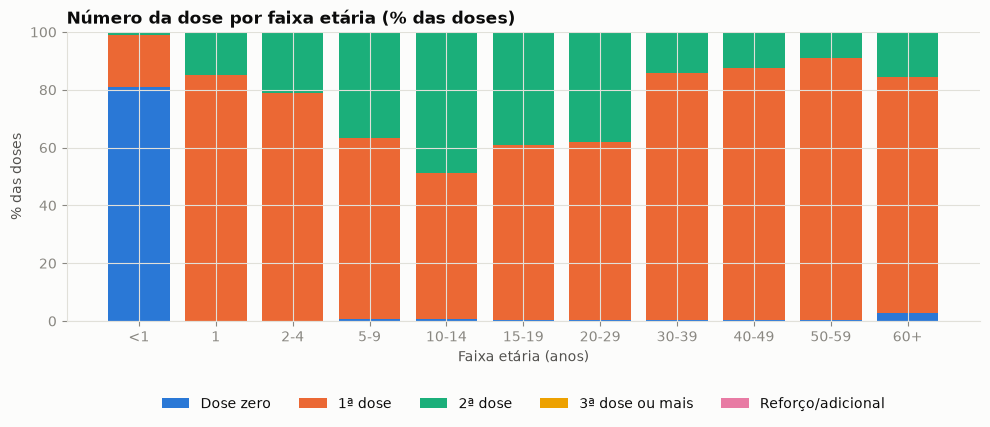

In [6]:
ordem_dose = ["Dose zero", "1ª dose", "2ª dose", "3ª dose ou mais", "Reforço/adicional"]
def dose_grupo(d):
    ref = d["descricao_dose_vacina"].str.contains("Refor|Adicional|Revacina", na=False) & d["dose_numero"].isna()
    n = d["dose_numero"].fillna(d["ordem_dose_paciente"].clip(upper=3)).astype(int)
    r = n.map({0: "Dose zero", 1: "1ª dose", 2: "2ª dose", 3: "3ª dose ou mais", 4: "3ª dose ou mais"}).astype("string")
    return r.mask(ref, "Reforço/adicional")
df["dose_grupo"] = dose_grupo(df)
t = pd.crosstab(df["faixa_etaria"], df["dose_grupo"]).reindex(index=ORDEM_IDADE, columns=ordem_dose).fillna(0)
fig, ax = plt.subplots(figsize=(10, 4.5))
empilhado_pct(ax, t, legenda_col=5); titulo(ax, "Número da dose por faixa etária (% das doses)"); ax.set_xlabel("Faixa etária (anos)")
plt.tight_layout(); plt.show()

## 4. Pessoa e intervalo entre doses

### 4.1 Do intervalo 1ª -> 2ª dose
Pacientes com ao menos duas doses na janela (excluindo IDs com mais de 10 doses, provável colisão). O calendário prevê a 2ª dose (tetra viral) aos 15 meses; intervalos muito curtos indicam registro duplicado ou dose de bloqueio, e muito longos, esquema atrasado.

2,687,454 pacientes com 1ª e 2ª dose na janela
count   2,687,454.00
mean          107.00
std            71.00
min             0.00
10%            35.00
25%            67.00
50%            92.00
75%           129.00
90%           194.00
max           544.00
Mesmo dia: 3.5% | até 30 dias: 6.7% | mais de 1 ano: 1.1%


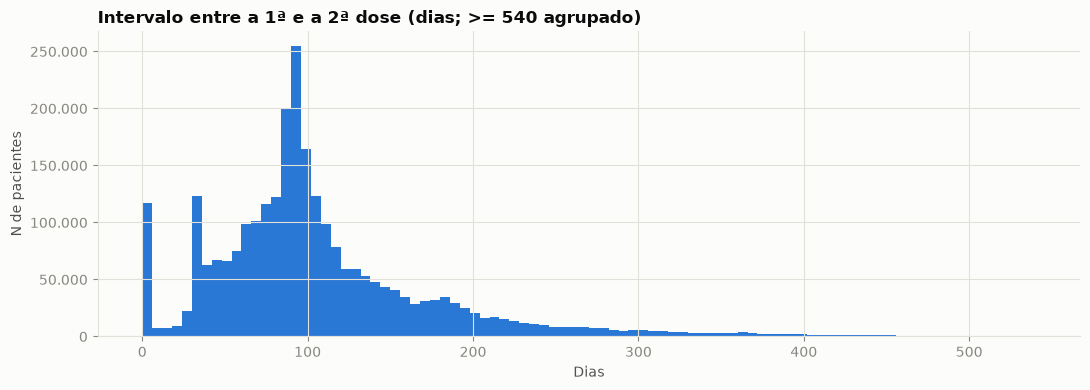

In [7]:
base = df[df["doses_paciente_janela"].between(2, 10)][["codigo_paciente_anonimizado", "ordem_dose_paciente", "data_vacinacao", "idade_paciente", "vacina_tipo"]]
d1 = base[base["ordem_dose_paciente"] == 1].rename(columns={"data_vacinacao": "data1", "idade_paciente": "idade1", "vacina_tipo": "vacina1"}).drop(columns="ordem_dose_paciente")
d2 = base[base["ordem_dose_paciente"] == 2].rename(columns={"data_vacinacao": "data2", "vacina_tipo": "vacina2"}).drop(columns=["ordem_dose_paciente", "idade_paciente"])
par = d1.merge(d2, on="codigo_paciente_anonimizado")
par["intervalo"] = (par["data2"] - par["data1"]).dt.days
print(f"{len(par):,} pacientes com 1ª e 2ª dose na janela")
print(par["intervalo"].describe(percentiles=[.1, .25, .5, .75, .9]).round(0).to_string())
print(f"Mesmo dia: {(par['intervalo'] == 0).mean() * 100:.1f}% | até 30 dias: {(par['intervalo'] <= 30).mean() * 100:.1f}% | mais de 1 ano: {(par['intervalo'] > 365).mean() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(par["intervalo"].clip(upper=540), bins=90, color=BLUE)
titulo(ax, "Intervalo entre a 1ª e a 2ª dose (dias; >= 540 agrupado)")
ax.set_xlabel("Dias"); ax.set_ylabel("N de pacientes"); milhar(ax)
plt.tight_layout(); plt.show()

Mediana do intervalo por idade na 1ª dose (crianças de 0 a 10 anos):

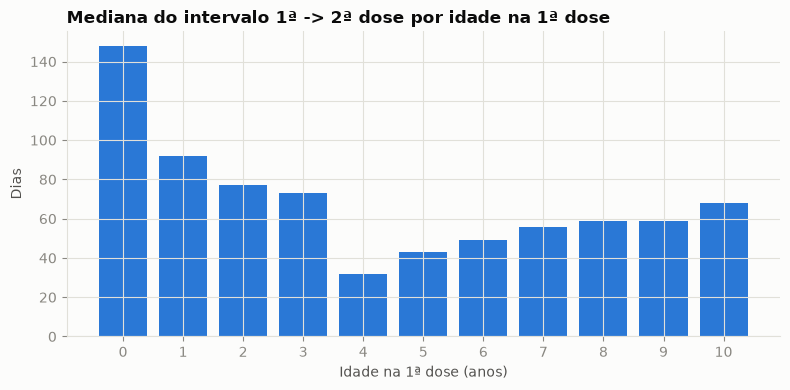

In [8]:
g = par[par["idade1"].between(0, 10)].groupby("idade1")["intervalo"].agg(["median", "count"])
g = g[g["count"] > 500]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(g.index.astype(int).astype(str), g["median"], color=BLUE)
titulo(ax, "Mediana do intervalo 1ª -> 2ª dose por idade na 1ª dose"); ax.set_xlabel("Idade na 1ª dose (anos)"); ax.set_ylabel("Dias")
plt.tight_layout(); plt.show()

## 5. Demografia

### 5.1 Sexo por faixa etária

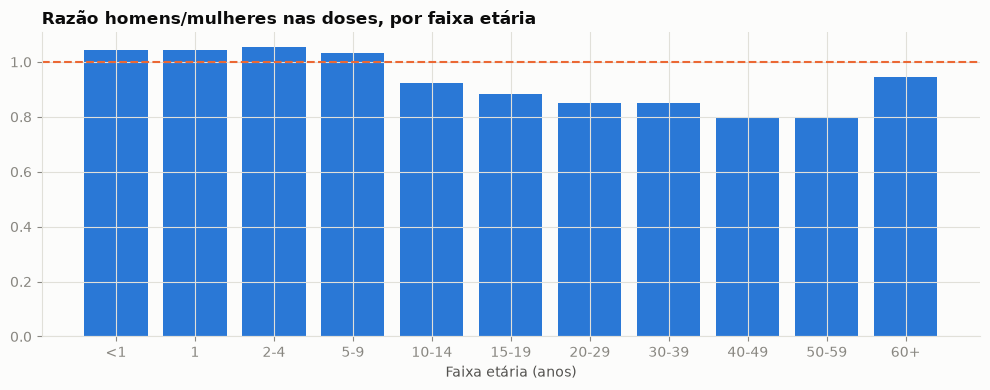

Ignorado: 70


In [9]:
t = pd.crosstab(df["faixa_etaria"], df["sexo_paciente"]).reindex(ORDEM_IDADE)
razao = (t["Masculino"] / t["Feminino"]).round(3)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(razao.index.astype(str), razao.values, color=BLUE); ax.axhline(1, color=CATEGORICAL[1], linestyle="--")
titulo(ax, "Razão homens/mulheres nas doses, por faixa etária"); ax.set_xlabel("Faixa etária (anos)")
plt.tight_layout(); plt.show()
print("Ignorado:", f"{(df['sexo_paciente'] == 'Ignorado').sum():,}")

### 5.2 Raça/cor por faixa etária
"Sem informação" alto em alguma faixa significa que o preenchimento varia com o serviço de origem, o que limita análises de equidade.

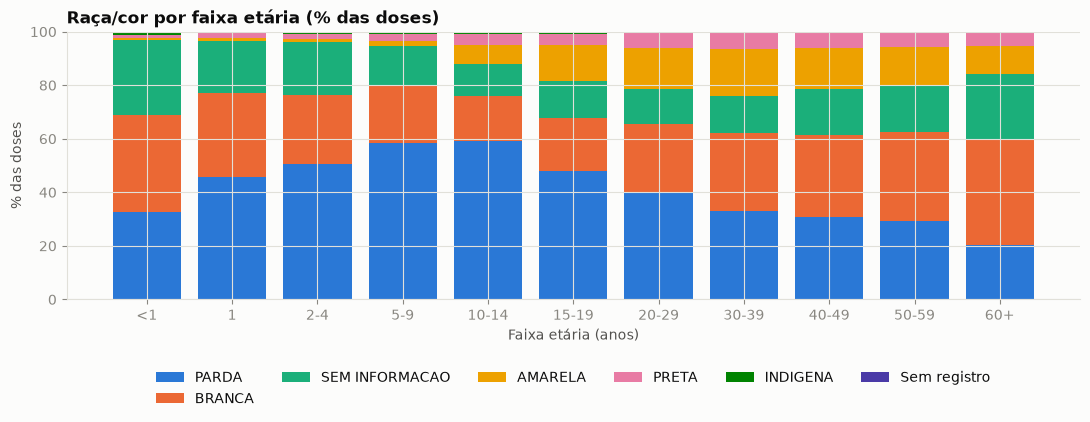

{'PARDA': 42.5, 'BRANCA': 29.7, 'SEM INFORMACAO': 18.1, 'AMARELA': 6.1, 'PRETA': 3.0, 'INDIGENA': 0.6, 'Sem registro': 0.0}


In [10]:
df["raca"] = df["raca_cor_paciente"].fillna(SEM)
t = pd.crosstab(df["faixa_etaria"], df["raca"]).reindex(ORDEM_IDADE)
ordem_col = t.sum().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 4.5))
pct = empilhado_pct(ax, t[ordem_col], legenda_col=6); titulo(ax, "Raça/cor por faixa etária (% das doses)"); ax.set_xlabel("Faixa etária (anos)")
plt.tight_layout(); plt.show()
print((df["raca"].value_counts(normalize=True) * 100).round(1).to_dict())

### 5.3 Nacionalidade e povos indígenas

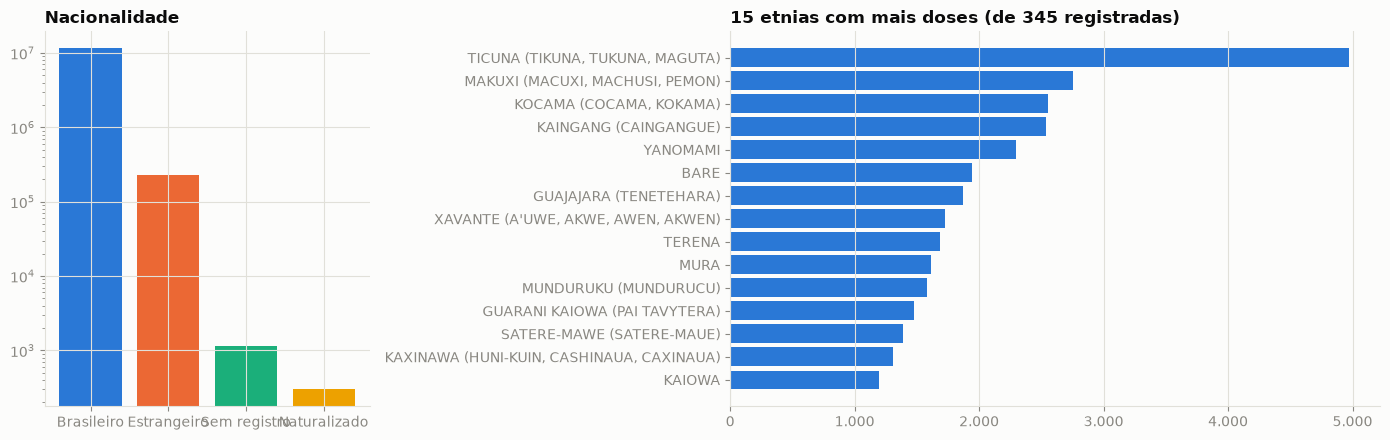

Doses em pessoas com etnia indígena informada: 55,532 (0.47%)


In [11]:
nac = df["nacionalidade_paciente"].fillna(SEM).map({"B": "Brasileiro", "E": "Estrangeiro", "N": "Naturalizado"}).fillna(SEM).value_counts()
ind = df["etnia_indigena_paciente"].dropna().value_counts().head(15).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].bar(nac.index, nac.values, color=CATEGORICAL[: len(nac)]); titulo(axes[0], "Nacionalidade"); milhar(axes[0])
axes[0].set_yscale("log")
axes[1].barh(ind.index, ind.values, color=BLUE); titulo(axes[1], f"15 etnias com mais doses (de {df['etnia_indigena_paciente'].nunique()} registradas)"); milhar(axes[1], "x"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("Doses em pessoas com etnia indígena informada:", f"{df['etnia_indigena_paciente'].notna().sum():,}", f"({df['etnia_indigena_paciente'].notna().mean() * 100:.2f}%)")

## 6. Geografia e deslocamento

### 6.1 Perfil etário de cada UF
UFs com mais doses em adultos indicam mais bloqueios/campanhas de atualização; as com mais crianças, vacinação de rotina.

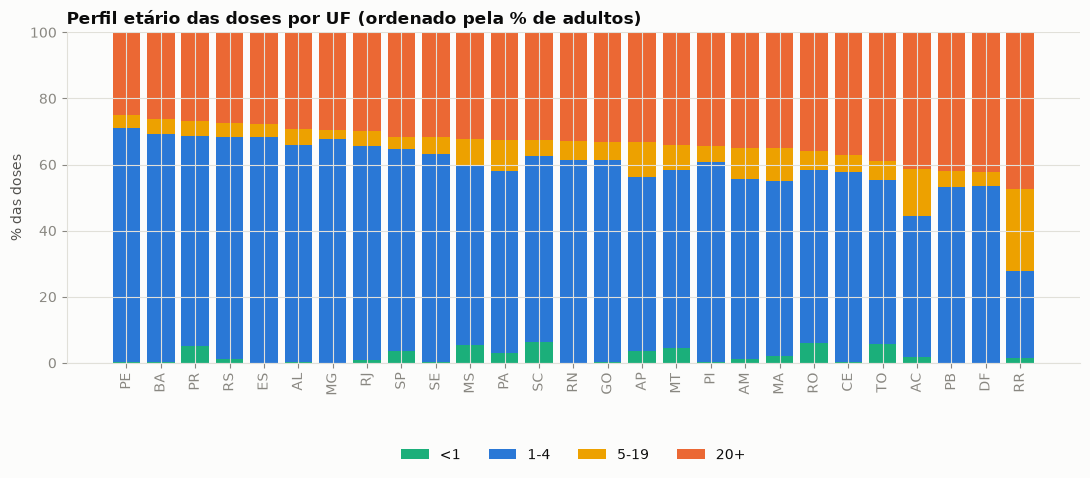

Maior % de adultos (20+): {'RR': 47.4, 'DF': 42.3, 'PB': 41.9} | menor: {'PE': 25.1, 'BA': 26.1, 'PR': 26.9}


In [12]:
df["grupo_etario"] = pd.cut(df["idade_paciente"].astype(float), [0, 1, 5, 20, 200], right=False, labels=["<1", "1-4", "5-19", "20+"])
t = pd.crosstab(df["uf_paciente"], df["grupo_etario"])
t = t[t.sum(axis=1) > 5000]
t = t.loc[(t["20+"] / t.sum(axis=1)).sort_values().index]
fig, ax = plt.subplots(figsize=(11, 5))
pct = empilhado_pct(ax, t, cores=[CATEGORICAL[2], BLUE, CATEGORICAL[3], CATEGORICAL[1]], legenda_col=4)
titulo(ax, "Perfil etário das doses por UF (ordenado pela % de adultos)")
ax.tick_params(axis="x", rotation=90); plt.tight_layout(); plt.show()
print("Maior % de adultos (20+):", pct["20+"].nlargest(3).round(1).to_dict(), "| menor:", pct["20+"].nsmallest(3).round(1).to_dict())

### 6.2 Deslocamento interestadual
Doses aplicadas em UF diferente da de residência do paciente (fronteiras, trabalho, turismo, registro errado).

Doses aplicadas fora da UF de residência: 576,636 (4.99%)


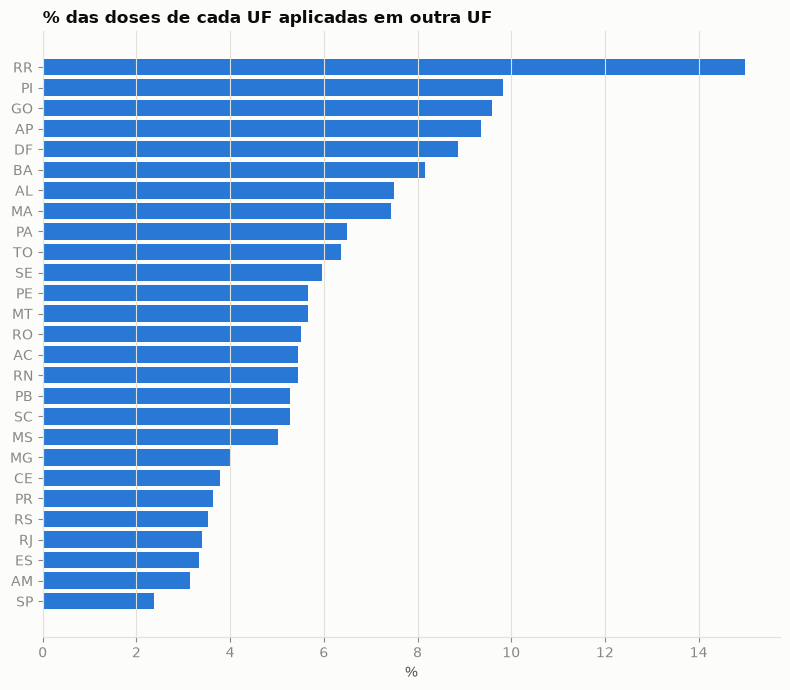

Maiores fluxos (residência -> aplicação):


uf_paciente  uf_estabelecimento
BA           SP                    26185
MG           SP                    15499
GO           DF                    12263
PE           SP                    10553
SP           MG                     9841
DF           GO                     8556
CE           SP                     8228
MA           SP                     8226
PI           SP                     7812
RJ           SP                     7688
dtype: int64

In [13]:
v = df[df["uf_paciente"].notna() & df["uf_estabelecimento"].notna()]
fora = (v["uf_paciente"] != v["uf_estabelecimento"])
print(f"Doses aplicadas fora da UF de residência: {fora.sum():,} ({fora.mean() * 100:.2f}%)")
por_uf = fora.groupby(v["uf_paciente"]).mean().mul(100)
por_uf = por_uf[v["uf_paciente"].value_counts()[por_uf.index] > 5000].sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(por_uf.index, por_uf.values, color=BLUE); titulo(ax, "% das doses de cada UF aplicadas em outra UF"); ax.set_xlabel("%"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
fluxo = v[fora].groupby(["uf_paciente", "uf_estabelecimento"]).size().nlargest(10)
print("Maiores fluxos (residência -> aplicação):"); fluxo

### 6.3 Concentração por município
Quão concentradas estão as doses nos maiores municípios.

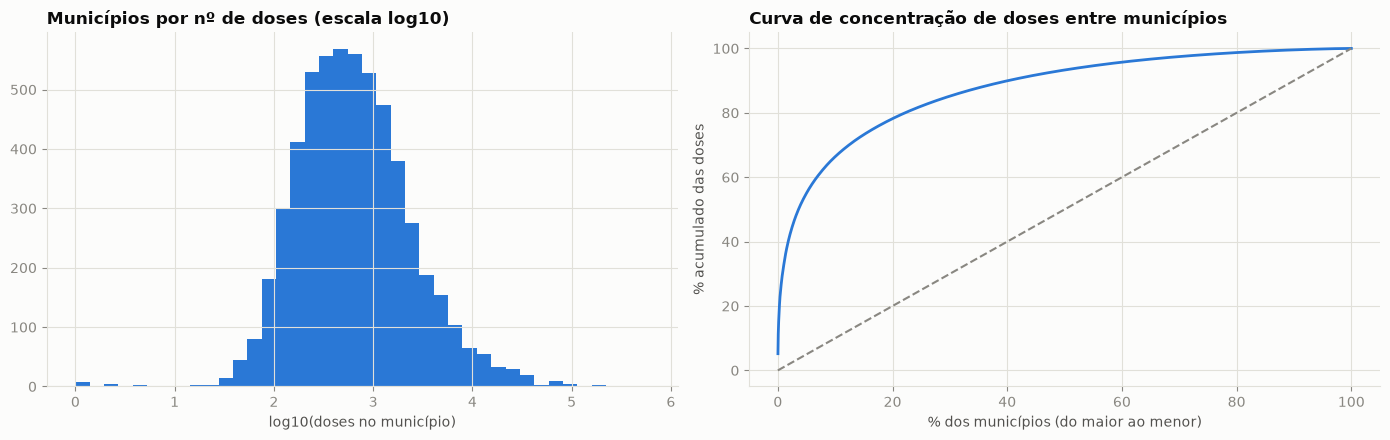

5,587 municípios | 10 maiores = 16.6% das doses | 10% maiores (558 municípios) = 66.4%


In [14]:
pm = df["codigo_municipio_paciente"].value_counts()
acum = pm.cumsum() / pm.sum() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(np.log10(pm.values), bins=40, color=BLUE); titulo(axes[0], "Municípios por nº de doses (escala log10)"); axes[0].set_xlabel("log10(doses no município)")
axes[1].plot(np.arange(1, len(acum) + 1) / len(acum) * 100, acum.values, color=BLUE, linewidth=2); axes[1].plot([0, 100], [0, 100], color=MUTED, linestyle="--")
titulo(axes[1], "Curva de concentração de doses entre municípios"); axes[1].set_xlabel("% dos municípios (do maior ao menor)"); axes[1].set_ylabel("% acumulado das doses")
plt.tight_layout(); plt.show()
n = len(pm)
print(f"{n:,} municípios | 10 maiores = {pm.head(10).sum() / pm.sum() * 100:.1f}% das doses | 10% maiores ({int(n * .1)} municípios) = {pm.head(int(n * .1)).sum() / pm.sum() * 100:.1f}%")

## 7. Estabelecimentos

### 7.1 Concentração por estabelecimento (CNES)

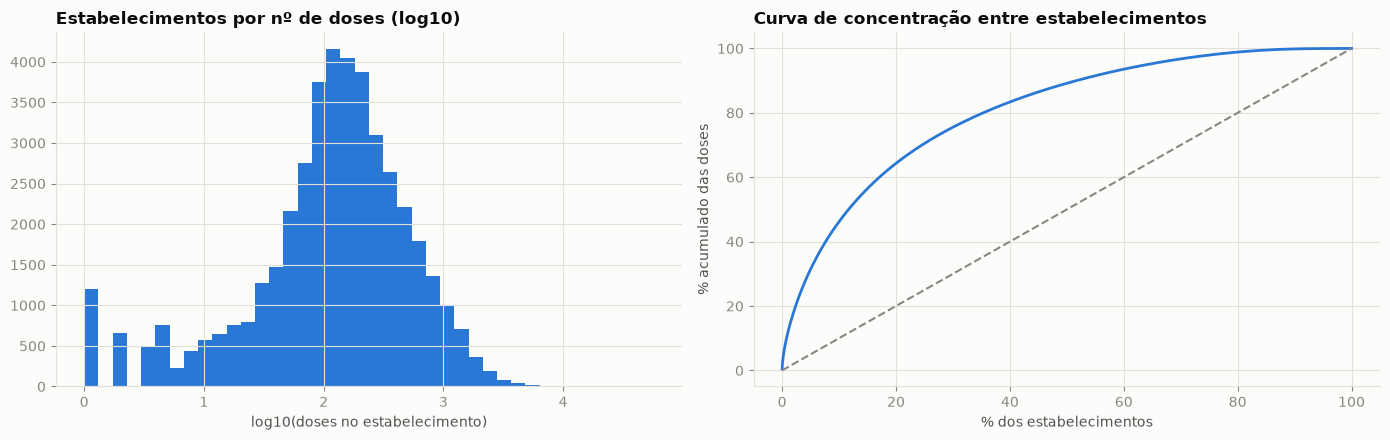

43,541 estabelecimentos | 10% maiores = 46.2% das doses | mediana = 135 doses/estabelecimento | maior = 57,006


In [15]:
pe = df["codigo_cnes_estabelecimento"].value_counts()
acum = pe.cumsum() / pe.sum() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(np.log10(pe.values), bins=40, color=BLUE); titulo(axes[0], "Estabelecimentos por nº de doses (log10)"); axes[0].set_xlabel("log10(doses no estabelecimento)")
axes[1].plot(np.arange(1, len(acum) + 1) / len(acum) * 100, acum.values, color=BLUE, linewidth=2); axes[1].plot([0, 100], [0, 100], color=MUTED, linestyle="--")
titulo(axes[1], "Curva de concentração entre estabelecimentos"); axes[1].set_xlabel("% dos estabelecimentos"); axes[1].set_ylabel("% acumulado das doses")
plt.tight_layout(); plt.show()
n = len(pe)
print(f"{n:,} estabelecimentos | 10% maiores = {pe.head(int(n * .1)).sum() / pe.sum() * 100:.1f}% das doses | mediana = {pe.median():.0f} doses/estabelecimento | maior = {pe.iloc[0]:,}")

### 7.2 Tipo de estabelecimento por faixa etária
Onde cada público é vacinado (UBS, clínica privada, hospital...).

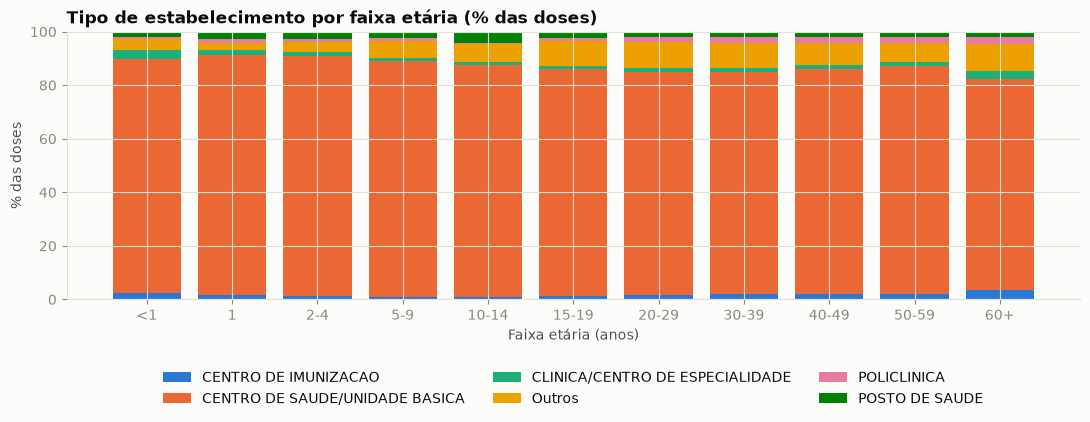

In [16]:
df["tipo_estab"] = df["tipo_estabelecimento"].fillna(SEM)
top = df["tipo_estab"].value_counts().head(5).index
df["tipo_estab_g"] = df["tipo_estab"].where(df["tipo_estab"].isin(top), "Outros")
t = pd.crosstab(df["faixa_etaria"], df["tipo_estab_g"]).reindex(ORDEM_IDADE)
fig, ax = plt.subplots(figsize=(11, 4.5))
empilhado_pct(ax, t, legenda_col=3); titulo(ax, "Tipo de estabelecimento por faixa etária (% das doses)"); ax.set_xlabel("Faixa etária (anos)")
plt.tight_layout(); plt.show()

### 7.3 Rede privada ao longo do tempo
Participação do setor privado (natureza jurídica de entidade empresarial) nas doses de cada mês.

Naturezas: {'ADMINISTRACAO PUBLICA': 11477320, 'ENTIDADES EMPRESARIAIS': 211201, 'ENTIDADES SEM FINS LUCRATIVOS': 57670, 'Sem registro': 10814, 'PESSOAS FISICAS': 572}


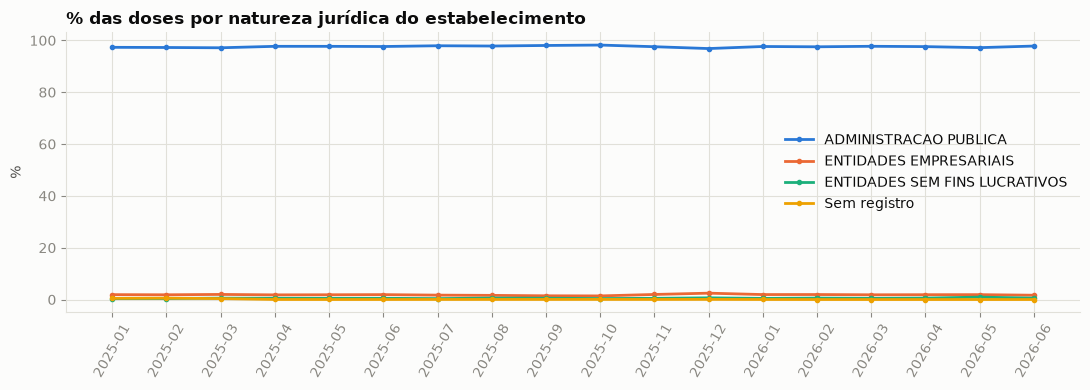

In [17]:
nat = pd.crosstab(df["ano_mes"], df["natureza_estabelecimento"].fillna(SEM))
print("Naturezas:", nat.sum().sort_values(ascending=False).to_dict())
pct = nat.div(nat.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 4))
for cor, col in zip(CATEGORICAL, pct.sum().sort_values(ascending=False).index[:4]):
    ax.plot(pct.index, pct[col], label=col, color=cor, linewidth=2, marker="o", markersize=3)
titulo(ax, "% das doses por natureza jurídica do estabelecimento"); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=60); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 8. Estratégias de vacinação

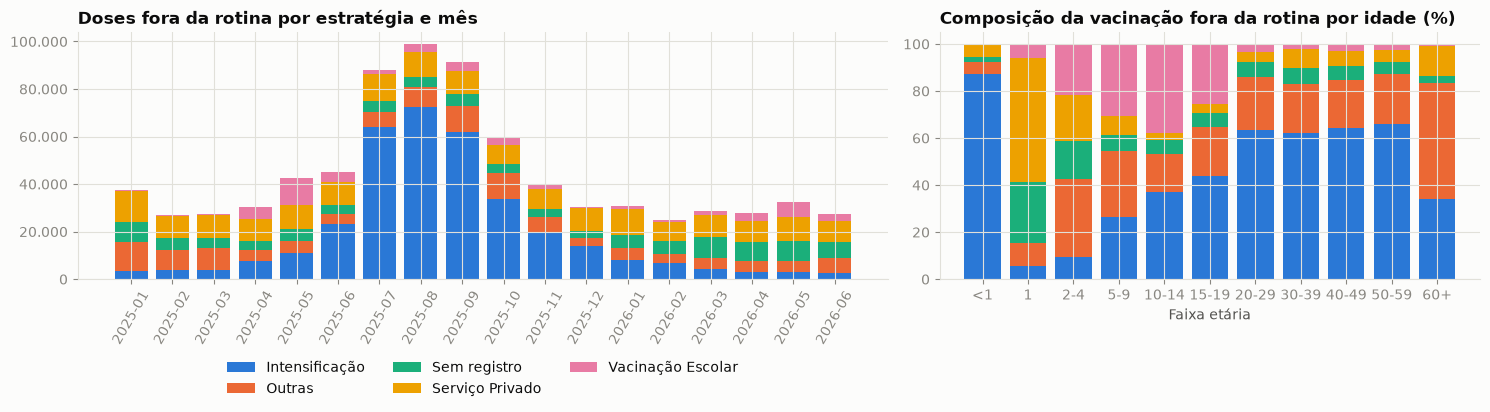

Rotina: 93.3% das doses


In [18]:
df["estrategia"] = df["estrategia_vacinacao"].fillna(SEM)
top = df["estrategia"].value_counts().head(5).index
df["estrategia_g"] = df["estrategia"].where(df["estrategia"].isin(top), "Outras")
fora = df[df["estrategia_g"] != "Rotina"]
t = pd.crosstab(fora["ano_mes"], fora["estrategia_g"])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [3, 2]})
base = np.zeros(len(t))
for cor, col in zip(CATEGORICAL, t.columns):
    axes[0].bar(t.index, t[col], bottom=base, label=col, color=cor); base += t[col].values
titulo(axes[0], "Doses fora da rotina por estratégia e mês"); axes[0].tick_params(axis="x", rotation=60); milhar(axes[0])
axes[0].legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.28))
t2 = pd.crosstab(fora["faixa_etaria"], fora["estrategia_g"]).reindex(ORDEM_IDADE)
pct = t2.div(t2.sum(axis=1), axis=0) * 100
b = np.zeros(len(pct))
for cor, col in zip(CATEGORICAL, pct.columns):
    axes[1].bar(pct.index.astype(str), pct[col], bottom=b, color=cor); b += pct[col].values
titulo(axes[1], "Composição da vacinação fora da rotina por idade (%)"); axes[1].set_xlabel("Faixa etária")
plt.tight_layout(); plt.show()
print(f"Rotina: {(df['estrategia_g'] == 'Rotina').mean() * 100:.1f}% das doses")

### Categoria de atendimento
Campo preenchido só em parte dos registros (o percentual aparece abaixo); indica os públicos-alvo prioritários.

Preenchido em 61.7% das doses


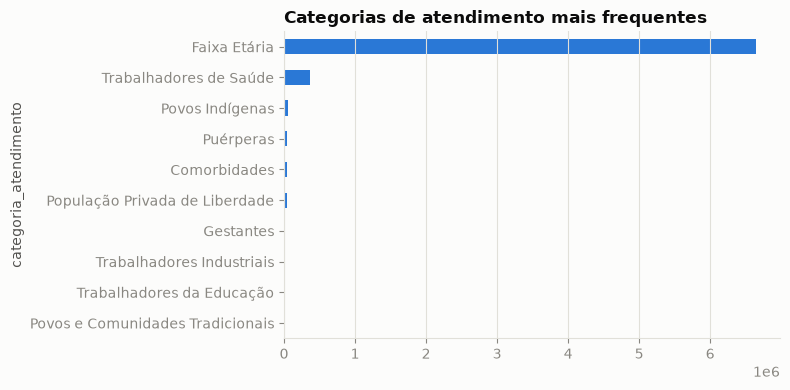

In [19]:
cat = df["categoria_atendimento"].value_counts()
print(f"Preenchido em {df['categoria_atendimento'].notna().mean() * 100:.1f}% das doses")
cat.head(10).iloc[::-1].plot.barh(figsize=(8, 4), color=BLUE); titulo(plt.gca(), "Categorias de atendimento mais frequentes"); plt.gca().grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 9. Adultos e campanhas de atualização
Adultos de 20 a 59 anos raramente entram na rotina. Picos nessa faixa apontam para bloqueios de surto ou campanhas de atualização.

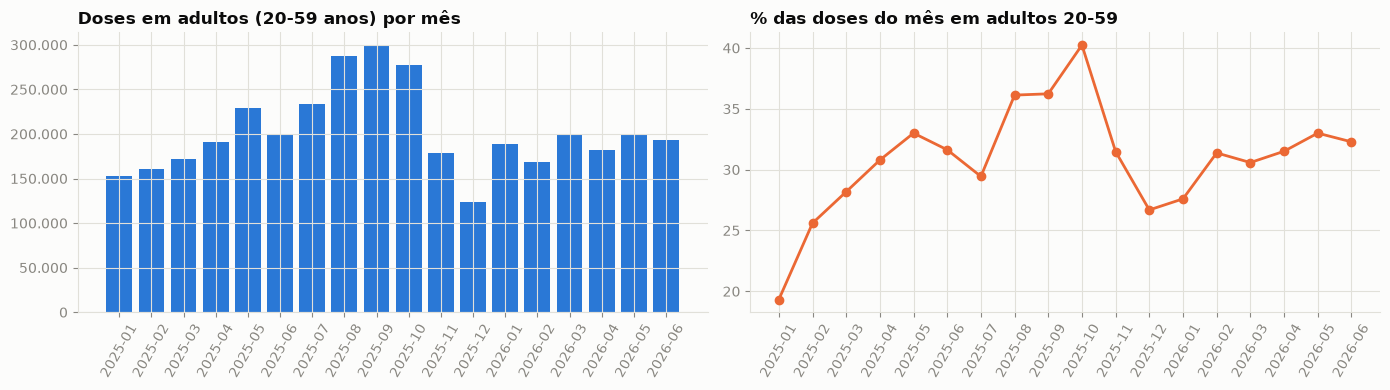

UFs com mais doses em adultos: {'SP': 676445, 'MG': 267216, 'RJ': 205148, 'CE': 195971, 'PA': 189677, 'MA': 182612, 'BA': 174969, 'PR': 169915}


In [20]:
ad = df[df["idade_paciente"].between(20, 59)]
por_mes = ad.groupby("ano_mes").size()
total = df.groupby("ano_mes").size()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(por_mes.index, por_mes.values, color=BLUE); titulo(axes[0], "Doses em adultos (20-59 anos) por mês"); axes[0].tick_params(axis="x", rotation=60); milhar(axes[0])
axes[1].plot(por_mes.index, (por_mes / total * 100).values, color=CATEGORICAL[1], linewidth=2, marker="o"); titulo(axes[1], "% das doses do mês em adultos 20-59"); axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()
uf_ad = ad.groupby("uf_paciente").size().nlargest(8)
print("UFs com mais doses em adultos:", uf_ad.to_dict())

### Adultos: campanhas por UF e mês
Célula = doses em adultos 20-59 na UF e mês, relativo à média da UF (100 = média). Manchas escuras isoladas = ação pontual.

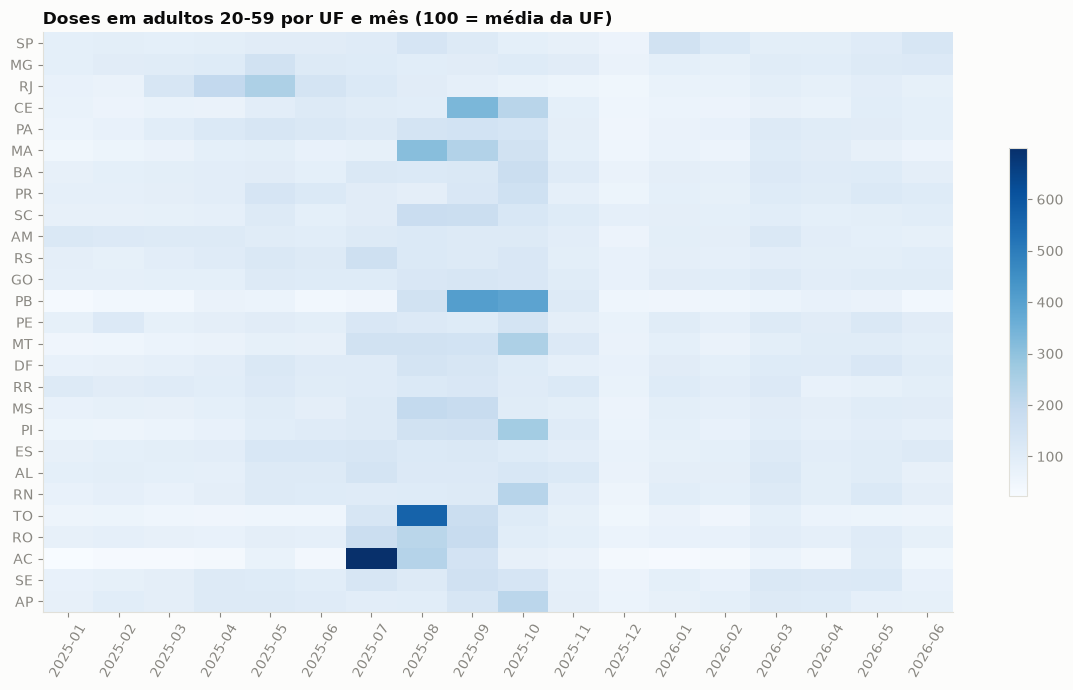

In [21]:
h = ad.groupby(["uf_paciente", "ano_mes"]).size().unstack().fillna(0)
h = h[h.sum(axis=1) > 5000]
rel = h.div(h.mean(axis=1), axis=0) * 100
rel = rel.loc[h.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(rel.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(rel.shape[1])); ax.set_xticklabels(rel.columns, rotation=60); ax.set_yticks(range(rel.shape[0])); ax.set_yticklabels(rel.index); ax.grid(False)
titulo(ax, "Doses em adultos 20-59 por UF e mês (100 = média da UF)"); fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout(); plt.show()

## 10. Síntese

In [22]:
tot = len(df)
print("SÍNTESE DA BASE")
print(f"- {tot:,} doses em {df['ano_mes'].nunique()} meses; {df['codigo_paciente_anonimizado'].nunique():,} pacientes distintos; {df['codigo_municipio_paciente'].nunique():,} municípios de residência; {df['codigo_cnes_estabelecimento'].nunique():,} estabelecimentos.")
print(f"- Crianças de 1-4 anos: {df['idade_paciente'].between(1, 4).mean() * 100:.1f}% das doses; adultos 20-59: {df['idade_paciente'].between(20, 59).mean() * 100:.1f}%.")
print(f"- SCR: {(df['vacina_tipo'] == 'Tríplice viral (SCR)').mean() * 100:.1f}% | SCRV: {(df['vacina_tipo'] == 'Tetra viral (SCRV)').mean() * 100:.1f}% | SR: {(df['vacina_tipo'] == 'Dupla viral (SR)').mean() * 100:.1f}%.")
print(f"- Rotina: {(df['estrategia_g'] == 'Rotina').mean() * 100:.1f}% | rede privada (entidades empresariais e pessoas físicas): {(df['natureza_estabelecimento'].fillna('') .isin(['ENTIDADES EMPRESARIAIS', 'PESSOAS FISICAS'])).mean() * 100:.1f}%.")
print(f"- Intervalo mediano 1ª -> 2ª dose: {par['intervalo'].median():.0f} dias.")
print(f"- Doses aplicadas fora da UF de residência: {(v['uf_paciente'] != v['uf_estabelecimento']).mean() * 100:.2f}%.")

SÍNTESE DA BASE


- 11,757,577 doses em 18 meses; 8,785,306 pacientes distintos; 5,587 municípios de residência; 43,541 estabelecimentos.
- Crianças de 1-4 anos: 60.9% das doses; adultos 20-59: 30.9%.


- SCR: 74.7% | SCRV: 24.3% | SR: 1.0%.


- Rotina: 93.3% | rede privada (entidades empresariais e pessoas físicas): 1.8%.
- Intervalo mediano 1ª -> 2ª dose: 92 dias.
- Doses aplicadas fora da UF de residência: 4.99%.


## Próximos passos
1. **Denominador populacional** (IBGE/SINASC por município e idade) para transformar doses em **cobertura vacinal** por município.
2. **Casos confirmados** (SINAN) x vacinação: cruzar surtos com queda de cobertura/atraso da 2ª dose, com os dados de `data/sarampo/`.
3. **Bloqueios**: usar os picos em adultos e a estratégia "Intensificação"/"Monitoramento" para identificar ações de resposta a surtos.
4. **Mapas** por município (malha IBGE) com as tabelas gold.